# 该脚本使用线性回归方法，删除数据残差较大的到时数据

In [1]:
# 载入 PyTomoATT 数据处理函数
import pytomoatt as pta
import matplotlib.pyplot as plt

# 1. 读取到时数据文件

2026-08-04 00:17:50,349 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.


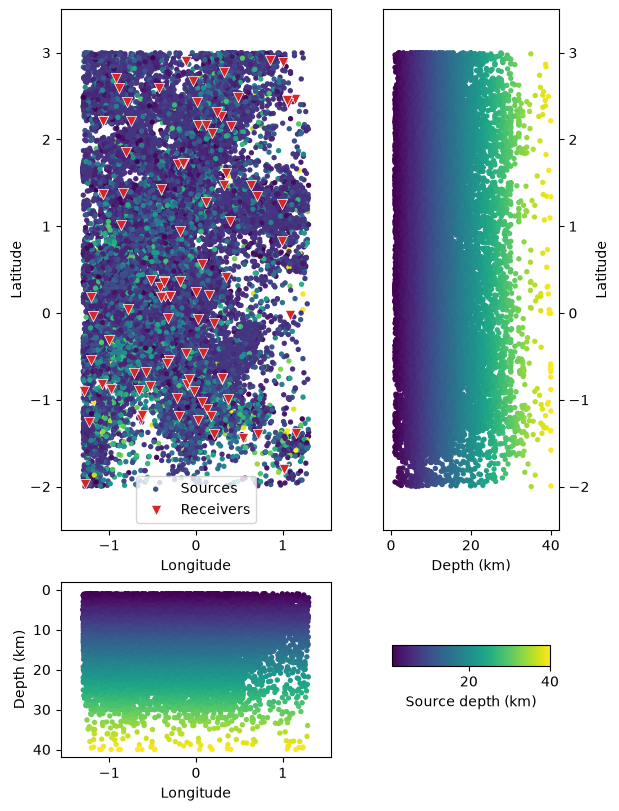

In [2]:
# 读取数据
fname = "output_data/step1_src_rec_indom.dat"
sr =pta.SrcRec.read(fname)

# 数据画图（可选） fname = None 可以不保存图片
sr.plot();

# 2. 初步删除 outlier 数据，避免这些极端偏离值影响计算回归直线

2026-08-04 00:18:39,973 [SrcRec] INFO: src_points before constant-velocity selection: 66337
2026-08-04 00:18:39,973 [SrcRec] INFO: rec_points before constant-velocity selection: 489987
2026-08-04 00:18:40,245 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.
2026-08-04 00:18:40,427 [SrcRec] INFO: src_points after constant-velocity selection: 66313
2026-08-04 00:18:40,427 [SrcRec] INFO: rec_points after constant-velocity selection: 488249


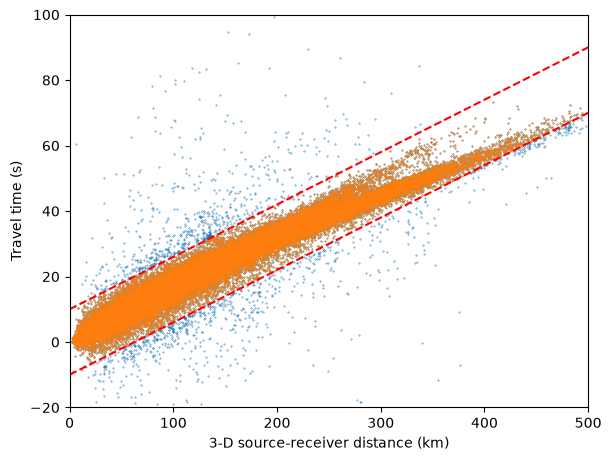

In [3]:
# 筛选范围：当 走时 > slope * 距离 + intercept + up 或者 走时 < slope * 距离 + intercept + down 时，认为是异常数据，剔除掉。
velocity = 6.25    # 斜率
tt_res_range = [-10, 10]     

# 地震与台站直线距离范围（hypocentral distance）
dis_min = 0 
dis_max = 500

sr.calc_distaz()
sr_outlier = sr.copy()
sr_outlier.select_by_constant_velocity(velocity, tt_res_range, distance="dist_3d_km")

# 数据画图（可选） fname = None 可以不保存图片
fig = sr.plot_travel_time(color='C0', s=0.1, ylim=(-20, 100), distance="dist_3d_km")
sr_outlier.plot_travel_time(
    color='C1', s=0.1, fig=fig, ylim="inherit", distance="dist_3d_km")

# 绘制走时残差上下限辅助线
fig.axes[0].axline((0, tt_res_range[0]), slope=1/velocity, color='red', linestyle='--')
fig.axes[0].axline((0, tt_res_range[1]), slope=1/velocity, color='red', linestyle='--')
fig.axes[0].set_xlim(0, 500)
fig.axes[0].set_ylim(-20, 100)
fig.savefig("figs/step2_data_remove_outlier.png", dpi=300, bbox_inches='tight', facecolor='w', edgecolor='w')


# 3. 删除震中距（epicentral distance）超过 100 km 的数据

从 震源距-走时 图像可发现，当震中距超过一定距离时（图中300 km时较为明显），会出现两支数据。

下面一支走时较小，是Pn波，上面一支走时较大，是Pg波

由于 TomoATT 计算的是首达时，因此在较小震中距时，应该使用 Pg 波，震中距较大时，使用Pn波。

但是由于区分两个震相的临界震中距依赖速度结构，Moho面位置，震源深度等因素，通常难以确定。

通常情况下，当震中距小于 100 km时，绝大多数首达震相是 Pg 波。为了避免数据污染，这里我们删除所有震中距大于 100 km的数据，同时删除明确的Pn震相，以确保数据确实是首达P波到时

2026-08-03 20:21:13,241 [SrcRec] INFO: rec_points before selection: 488249
2026-08-03 20:21:13,483 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.
2026-08-03 20:21:13,945 [SrcRec] INFO: rec_points after selection: 270682
2026-08-03 20:21:13,950 [SrcRec] INFO: rec_points before selection: 270682
2026-08-03 20:21:14,172 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.
2026-08-03 20:21:14,619 [SrcRec] INFO: rec_points after selection: 268704
2026-08-03 20:21:14,644 [SrcRec] INFO: rec_points before selection: 268704
2026-08-03 20:21:14,799 [SrcRec] WARNING: Found conflicting coordinates/elevations for 1 receiver(s): ARPR.
2026-08-03 20:21:15,080 [SrcRec] INFO: rec_points after selection: 156232
2026-08-03 20:21:15,404 [SrcRec] INFO: rec_points before selection: 268704
2026-08-03 20:21:15,531 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.
2026-08-03 20:21:15,722 [SrcRec

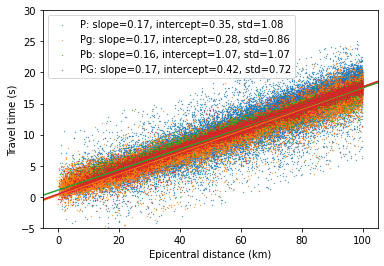

In [4]:
sr_phase = sr_outlier.copy()

# 删除震中距在 [epi_dis1, epi_dis2] 范围之内的数据
epi_range = [0, 100] # 单位是km
sr_phase.select_by_distance(epi_range, distance="dist_km")

# 在 100 km 以内的震中距范围内，Pn 通常不是首达震相，删除该震相（只保留 P, Pg, Pb震相）
phase_list = ["P", "Pg", "Pb", "PG"]
sr_phase.select_by_phase(phase_list)
# ev_limit_dis_phase = ffd.limit_data_phase(ev_limit_dis,phase_list)

# 数据画图（可选）
fig = plt.figure()
for i, ph in enumerate(phase_list):
    sr_pl = sr_phase.copy()
    sr_pl.select_by_phase([ph])
    slope, intercept, residual_std = sr_pl.linear_regression(distance="dist_3d_km")
    color = f"C{i}"
    sr_pl.plot_travel_time(
        s=0.1, ylim=(-5, 30), fig=fig, distance="dist_km",
        color=color, fname="figs/step2_data_limit_distance.png",
        label=f"{ph}: slope={slope:.2f}, intercept={intercept:.2f}, std={residual_std:.2f}"
    )
    fig.axes[0].axline((0, intercept), slope=slope, color=color)
fig.axes[0].legend()
    


# 4. 对走时数据进行线性回归，
### 保留残差小于 3 倍标准估计误差（standard error of the estimate, SEE）的走时数据

2026-08-03 20:21:23,946 [SrcRec] INFO: rec_points before travel-time selection: 268704


2026-08-03 20:21:24,380 [SrcRec] WARNING: Found conflicting coordinates/elevations for 2 receiver(s): GAZ, ARPR.
2026-08-03 20:21:24,819 [SrcRec] INFO: rec_points after travel-time selection: 263371


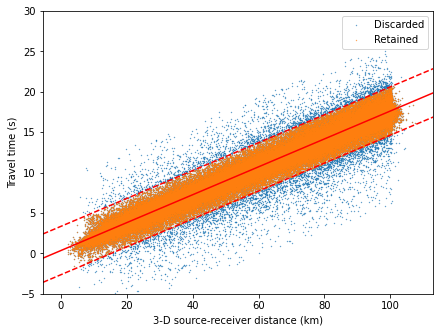

In [5]:
# 删除3倍标准差以外的数据
std_multiplier = 3
sr_lr = sr_phase.copy()
reg_para = sr_lr.select_by_linear_regression(std_multiplier=std_multiplier, separate_phase=False)

# 数据画图（可选）
# 绘制剔除异常数据前后的走时图
fig = sr_phase.plot_travel_time(
        s=0.1, color="C0", distance="dist_3d_km", ylim=(-5, 30), label="Discarded"
    )
sr_lr.plot_travel_time(
        s=0.1, color="C1", distance="dist_3d_km", fig=fig, ylim="inherit", label="Retained",
        fname="figs/step2_data_remove_outlier_3SEE.png",
    )
fig.axes[0].legend()

# 绘制线性回归线
fig.axes[0].axline((0, reg_para['all'][1]), slope=reg_para['all'][0], color="red", label="Linear Regression")

# 绘制线性回归线的上下3倍标准差线
fig.axes[0].axline((0, reg_para['all'][1]+std_multiplier*reg_para['all'][2]), slope=reg_para['all'][0], color="red", ls="--")
fig.axes[0].axline((0, reg_para['all'][1]-std_multiplier*reg_para['all'][2]), slope=reg_para['all'][0], color="red", ls="--")


# 5. 数据输出

In [6]:
# 将数据输出到指定目录
import os

# 指定数据目录
out_path = "output_data"
os.makedirs(out_path,exist_ok=True)

# 储存为TomoATT格式数据文件
out_fname = f"{out_path}/step2_src_rec_remove_outlier.dat"
sr_lr.write(out_fname)

Writing src_rec file: 100%|██████████| 64806/64806 [00:00<00:00, 77904.55it/s]
